# 04 · Linear Classifiers from Scratch

Classification predicts a **category** (spam / not spam, benign / malignant). We build the
two most important linear classifiers ourselves and connect them back to the math:

- **Logistic regression** — the direct descendant of MLE with a Bernoulli assumption; we
  implement it with gradient descent.
- **Naive Bayes** — probability's Bayes rule applied with a simplifying independence
  assumption; famously effective on text.

We finish by seeing what "linear" means geometrically: a straight **decision boundary**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
np.random.seed(0)

## 1. The logistic (sigmoid) function

A linear model outputs any real number, but a probability must live in [0, 1]. The **sigmoid**
squashes the real line into that range: large positive → near 1, large negative → near 0,
zero → exactly 0.5. Logistic regression is just "linear model, then sigmoid".

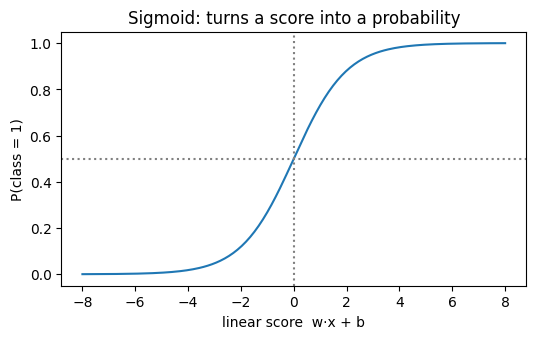

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6, 3.3))
plt.plot(z, sigmoid(z))
plt.axhline(0.5, color="gray", ls=":"); plt.axvline(0, color="gray", ls=":")
plt.title("Sigmoid: turns a score into a probability")
plt.xlabel("linear score  w·x + b"); plt.ylabel("P(class = 1)"); plt.show()

## 2. Logistic regression by gradient descent

The loss is **cross-entropy** (log loss) — the MLE objective when outcomes are Bernoulli.
Beautifully, its gradient has the *same clean shape* as linear regression's:
`(1/n) · Xᵀ (predictions − y)`. We implement the whole training loop in a few lines.

training accuracy: 92.5%


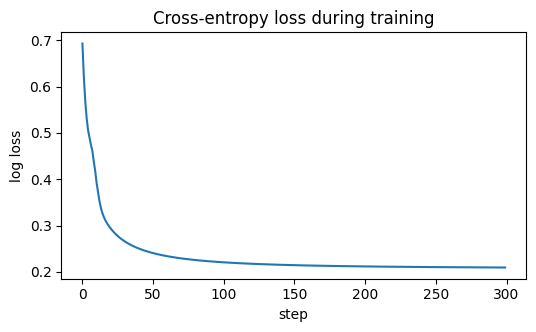

In [3]:
# Two clearly separated classes
X, y = make_blobs(n_samples=200, centers=2, cluster_std=1.3, random_state=4)

Xb = np.c_[np.ones(len(X)), X]          # add bias column
w = np.zeros(Xb.shape[1])
lr = 0.1
loss_hist = []
for step in range(300):
    p = sigmoid(Xb @ w)
    grad = Xb.T @ (p - y) / len(y)      # cross-entropy gradient
    w -= lr * grad
    eps = 1e-9
    loss = -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))
    loss_hist.append(loss)

acc = np.mean((sigmoid(Xb @ w) > 0.5) == y)
print(f"training accuracy: {acc:.1%}")

plt.figure(figsize=(6, 3.2))
plt.plot(loss_hist); plt.title("Cross-entropy loss during training")
plt.xlabel("step"); plt.ylabel("log loss"); plt.show()

## 3. The decision boundary is a straight line

"Linear classifier" means the surface separating the classes is a line (in 2-D) or a flat
plane (in higher dimensions). Everything on one side is predicted class 1, the other class 0.
Let's draw it.

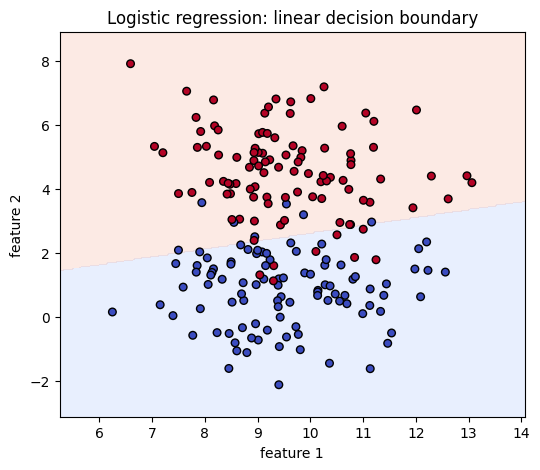

In [4]:
# Build a grid, predict every point, shade by class
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
grid = np.c_[np.ones(xx.size), xx.ravel(), yy.ravel()]
zz = (sigmoid(grid @ w) > 0.5).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, alpha=0.2, cmap="coolwarm")
plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm", edgecolor="k", s=30)
plt.title("Logistic regression: linear decision boundary")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.show()

## 4. Confirm against scikit-learn

Our hand-built model should match the library. In practice you'd always use the library —
but building it once means you *know what it's doing*.

In [5]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression().fit(X, y)
print("sklearn accuracy:", clf.score(X, y))
print("our accuracy:    ", acc)

sklearn accuracy: 0.935
our accuracy:     0.925


## 5. Naive Bayes: classification via Bayes' rule

Naive Bayes flips the question with **Bayes' theorem**: instead of modeling the boundary, it
models each class's feature distribution and asks "which class makes this sample most
probable?" The "naive" part is assuming features are independent given the class — often
false, yet it works remarkably well, especially for text. Here it is on a classic dataset.

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

data = load_breast_cancer()
Xtr, Xte, ytr, yte = train_test_split(data.data, data.target,
                                      test_size=0.3, random_state=0, stratify=data.target)
nb = GaussianNB().fit(Xtr, ytr)
print(f"Gaussian Naive Bayes test accuracy: {nb.score(Xte, yte):.1%}")

# It also gives calibrated-ish probabilities, not just labels
probs = nb.predict_proba(Xte[:3])
for i, p in enumerate(probs):
    print(f"sample {i}: P(malignant)={p[0]:.3f}  P(benign)={p[1]:.3f}")

Gaussian Naive Bayes test accuracy: 92.4%
sample 0: P(malignant)=1.000  P(benign)=0.000
sample 1: P(malignant)=0.000  P(benign)=1.000
sample 2: P(malignant)=1.000  P(benign)=0.000


## Recap

- **Sigmoid** turns a linear score into a probability; logistic regression = linear + sigmoid.
- Its loss is **cross-entropy** (Bernoulli MLE); the gradient is `Xᵀ(p − y)/n`.
- A linear classifier draws a **straight decision boundary**.
- **Naive Bayes** applies Bayes' rule with an independence shortcut — cheap, fast, strong on text.

**Next:** we switch from building models to *wielding* them — `05 — Supervised Learning with
scikit-learn`.